# Experiment 1: EMBER2024 Win64 Seed 43 Sanitizer Results

This notebook reads the compact sanitizer snapshot for the completed Experiment 1 matrix. Scope: **EMBER2024 Win64, seed 43, 1% poisoning, random and distribution-based sampling, eight value selectors, and Isolation Forest, Spectral Signature, and HDBSCAN**.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
TABLE_DIR = PROJECT_ROOT / 'results' / 'experiment 1' / 'tables' / 'sanitizer_metrics_seed43_win64'
EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'experiment_1' / 'results' / 'exports'
FIGURE_DIR = PROJECT_ROOT / 'notebooks' / 'experiment_1' / 'results' / 'figures'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
manifest = json.loads((TABLE_DIR / 'sanitizer_metrics_seed43_win64_manifest.json').read_text())
seed_level = pd.read_csv(TABLE_DIR / 'sanitizer_metrics_seed43_win64_seed_level.csv')
summary = pd.read_csv(TABLE_DIR / 'sanitizer_metrics_seed43_win64_summary.csv')
coverage = pd.read_csv(TABLE_DIR / 'sanitizer_metrics_seed43_win64_coverage.csv')
effectiveness = pd.read_csv(TABLE_DIR / 'sanitizer_effectiveness_seed43_win64.csv')
print(json.dumps(manifest['scope'], indent=2))
print(f"Completed: {manifest['completed_rows']}/{manifest['expected_rows']} sanitizer results")

{
  "dataset": "EMBER2024 Win64",
  "seed": 43,
  "sampling": [
    "random",
    "distribution_based_distance"
  ],
  "poison_rate": 0.01,
  "selectors": [
    "min_population_new",
    "argmin_Nv_sum_abs_shap",
    "combined_shap",
    "low_shap_signed",
    "frequency_bounded_signed_shap",
    "corr_count_abs_shap",
    "benign_prototype",
    "quantile_95"
  ],
  "sanitizers": [
    "isolation_forest",
    "spectral_signature",
    "hdbscan"
  ],
  "target_features": "problem_space_conservative"
}
Completed: 48/48 sanitizer results


## Coverage Audit
A missing configuration is reported explicitly and is never treated as zero recall.

In [2]:
coverage_table = coverage.pivot_table(index=['sampling_strategy', 'selector', 'sanitizer'], values='status', aggfunc='first').reset_index()
display(coverage_table)
display(coverage[coverage.status != 'complete']) if (coverage.status != 'complete').any() else print('All 48 expected configurations are complete.')

,sampling_strategy,selector,sanitizer,status
0,distribution_based_distance,BenignPrototype,HDBSCAN,complete
1,distribution_based_distance,BenignPrototype,Isolation Forest,complete
2,distribution_based_distance,BenignPrototype,Spectral Signature,complete
3,distribution_based_distance,CombinedSHAP*,HDBSCAN,complete
4,distribution_based_distance,CombinedSHAP*,Isolation Forest,complete
5,distribution_based_distance,CombinedSHAP*,Spectral Signature,complete
6,distribution_based_distance,CorrCountAbsSHAP,HDBSCAN,complete
7,distribution_based_distance,CorrCountAbsSHAP,Isolation Forest,complete
8,distribution_based_distance,CorrCountAbsSHAP,Spectral Signature,complete
9,distribution_based_distance,CountAbsSHAP*,HDBSCAN,complete


All 48 expected configurations are complete.


## Seed-Level Sanitizer Metrics
Poison recall is the percentage of known poisoned benign training rows removed by the sanitizer. The table also retains benign removals, clean false-positive rate, and removal precision.

In [3]:
display(seed_level[['sampling_strategy', 'selector', 'sanitizer', 'poison_recall_percent', 'removed_poisoned_rows', 'removed_clean_rows', 'clean_false_positive_rate_percent', 'poison_removal_precision_percent']].round(2))

,sampling_strategy,selector,sanitizer,poison_recall_percent,removed_poisoned_rows,removed_clean_rows,clean_false_positive_rate_percent,poison_removal_precision_percent
0,distribution_based_distance,CountAbsSHAP*,HDBSCAN,62.74,1305,44979,44.13,2.82
1,distribution_based_distance,CountAbsSHAP*,Isolation Forest,100.00,2080,0,0.00,100.00
2,distribution_based_distance,CountAbsSHAP*,Spectral Signature,68.37,1422,658,0.65,68.37
3,distribution_based_distance,BenignPrototype,HDBSCAN,50.00,1040,42090,41.30,2.41
4,distribution_based_distance,BenignPrototype,Isolation Forest,0.00,0,2080,2.04,0.00
5,distribution_based_distance,BenignPrototype,Spectral Signature,0.00,0,2080,2.04,0.00
6,distribution_based_distance,CombinedSHAP*,HDBSCAN,38.51,801,42121,41.33,1.87
7,distribution_based_distance,CombinedSHAP*,Isolation Forest,2.26,47,2033,1.99,2.26
8,distribution_based_distance,CombinedSHAP*,Spectral Signature,8.65,180,1900,1.86,8.65
9,distribution_based_distance,CorrCountAbsSHAP,HDBSCAN,40.53,843,41854,41.07,1.97


## Poison Recall by Sampling and Sanitizer

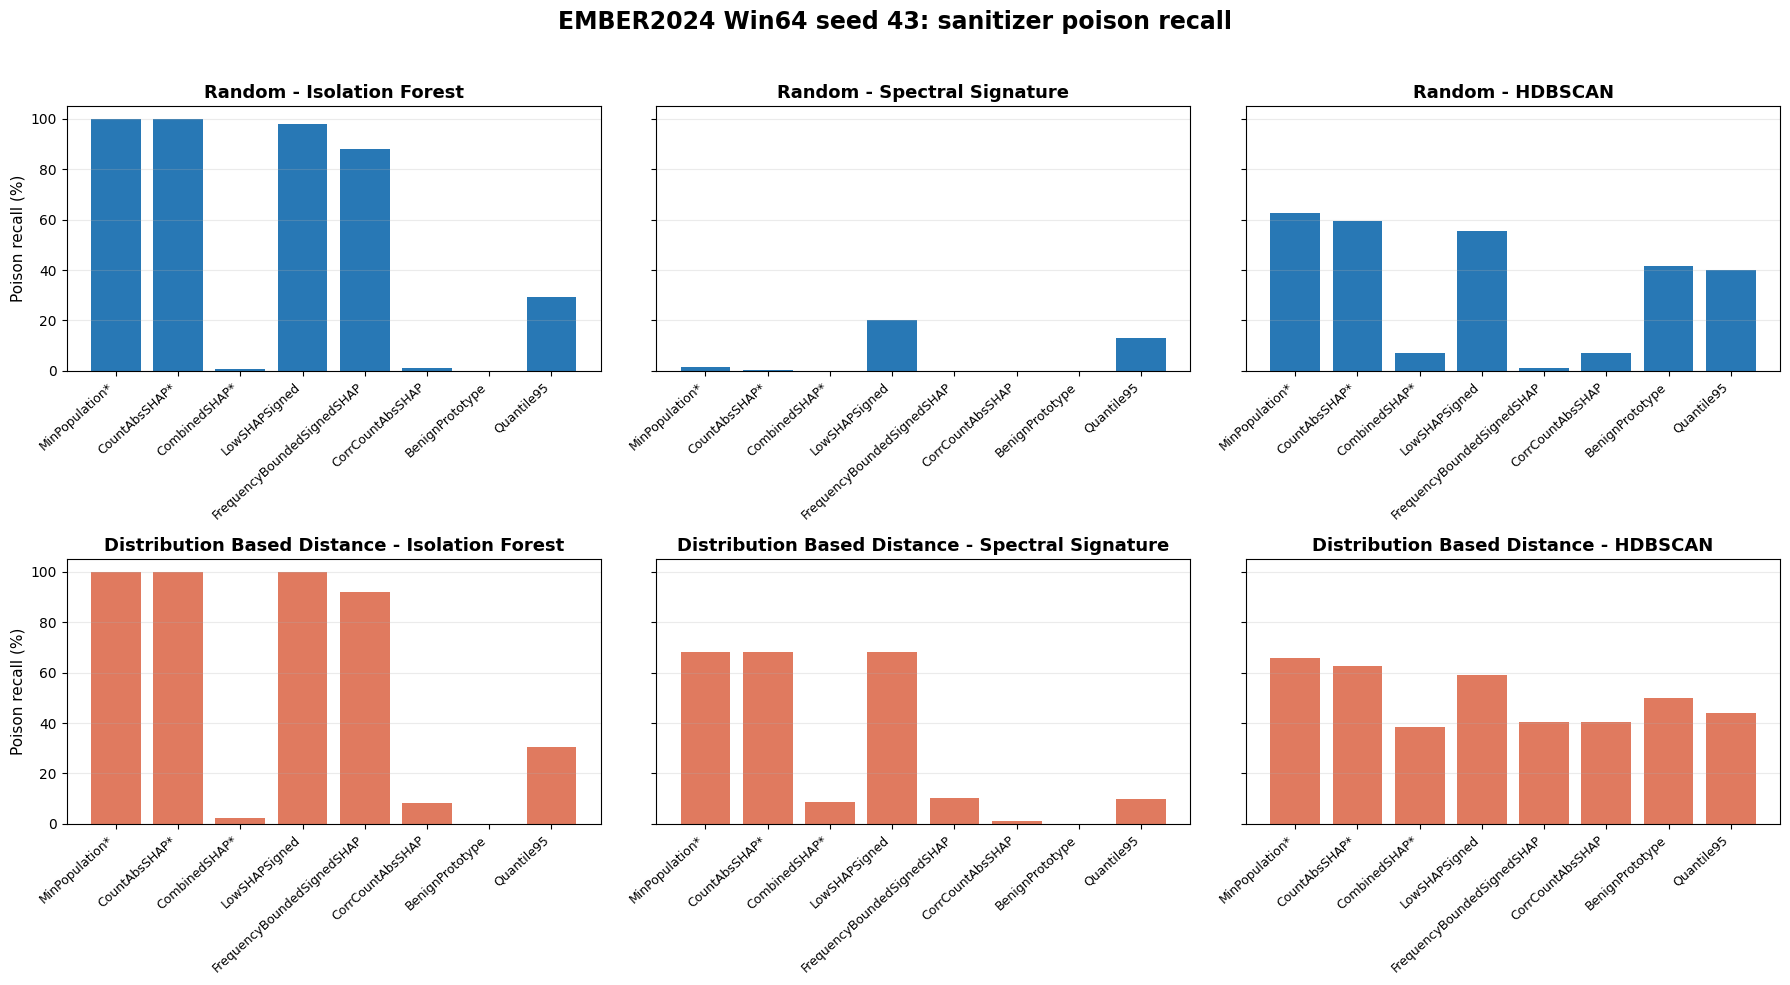

In [4]:
selector_order = ['MinPopulation*', 'CountAbsSHAP*', 'CombinedSHAP*', 'LowSHAPSigned', 'FrequencyBoundedSignedSHAP', 'CorrCountAbsSHAP', 'BenignPrototype', 'Quantile95']
sampling_order = ['random', 'distribution_based_distance']
sanitizer_order = ['Isolation Forest', 'Spectral Signature', 'HDBSCAN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
x = np.arange(len(selector_order))
for row, sampling in enumerate(sampling_order):
    for col, sanitizer in enumerate(sanitizer_order):
        ax = axes[row, col]
        panel = seed_level[(seed_level.sampling_strategy == sampling) & (seed_level.sanitizer == sanitizer)].set_index('selector').reindex(selector_order)
        ax.bar(x, panel.poison_recall_percent, color='#2878B5' if sampling == 'random' else '#E07A5F')
        ax.set_title(f'{sampling.replace("_", " ").title()} - {sanitizer}', fontsize=13, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.grid(axis='y', alpha=0.25)
        ax.set_xticks(x, selector_order, rotation=42, ha='right', fontsize=9)
        if col == 0: ax.set_ylabel('Poison recall (%)', fontsize=11)
fig.suptitle('EMBER2024 Win64 seed 43: sanitizer poison recall', fontsize=17, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.96))
for suffix in ('png', 'pdf'): fig.savefig(FIGURE_DIR / f'seed43_win64_sanitizer_poison_recall.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

## Attack Effectiveness and Detectability
ASR is the attack effectiveness value from the corresponding baseline summary. Poison recall is the sanitizer detectability signal. This plot is descriptive for the fixed seed-43 experiment.

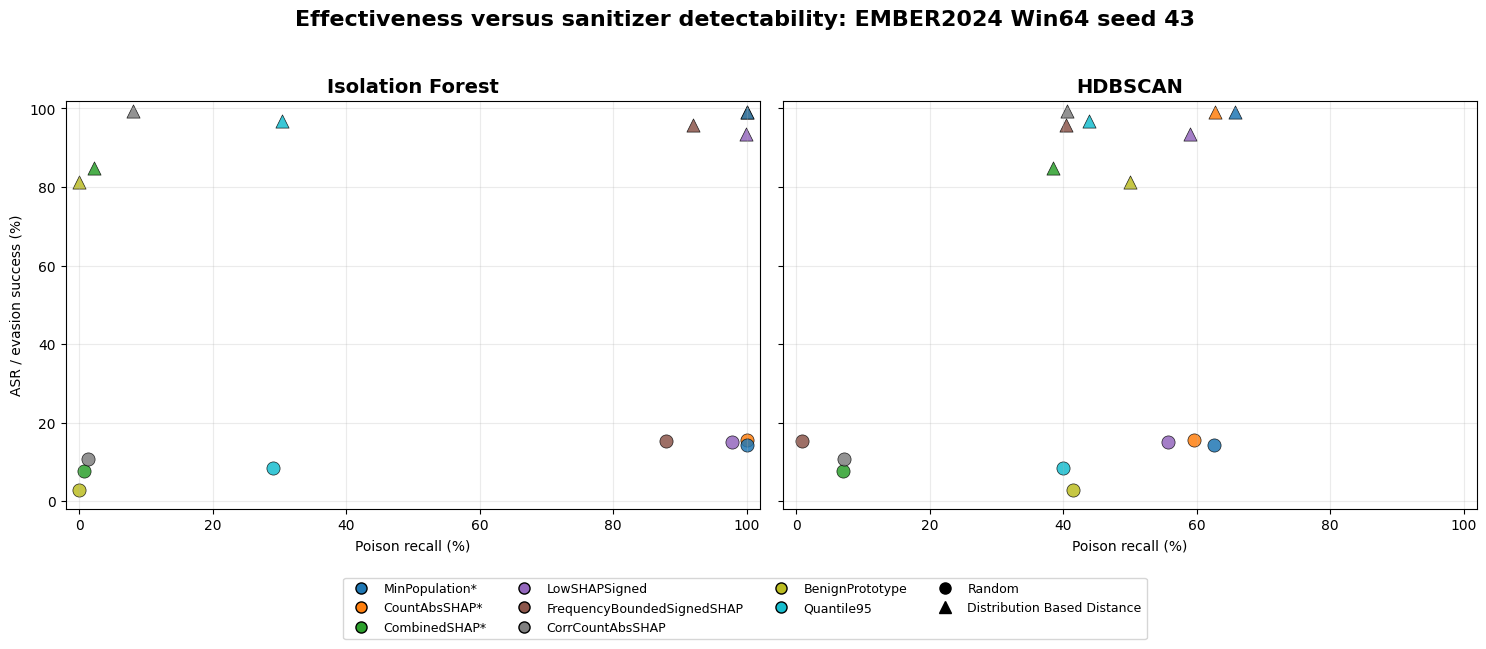

In [5]:
plot_data = seed_level.merge(effectiveness[['sampling_strategy', 'selector', 'asr_percent', 'clean_accuracy_percent']], on=['sampling_strategy', 'selector'], how='left')
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
colors = dict(zip(selector_order, plt.cm.tab10(np.linspace(0, 1, len(selector_order)))))
markers = {'random': 'o', 'distribution_based_distance': '^'}
for ax, sanitizer in zip(axes, ['Isolation Forest', 'HDBSCAN']):
    panel = plot_data[plot_data.sanitizer == sanitizer]
    for _, r in panel.iterrows(): ax.scatter(r.poison_recall_percent, r.asr_percent, s=90, marker=markers[r.sampling_strategy], color=colors[r.selector], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_title(sanitizer, fontsize=14, fontweight='bold')
    ax.set_xlabel('Poison recall (%)')
    ax.set_xlim(-2, 102); ax.set_ylim(-2, 102); ax.grid(alpha=0.25)
axes[0].set_ylabel('ASR / evasion success (%)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[s], markeredgecolor='black', label=s, markersize=8) for s in selector_order]
handles += [plt.Line2D([0], [0], marker=m, color='black', linestyle='None', label=s.replace('_', ' ').title(), markersize=8) for s, m in markers.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08), fontsize=9)
fig.suptitle('Effectiveness versus sanitizer detectability: EMBER2024 Win64 seed 43', fontsize=16, fontweight='bold')
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
for suffix in ('png', 'pdf'): fig.savefig(FIGURE_DIR / f'seed43_win64_effectiveness_vs_detectability.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

## Compact Exports
These CSV files remain usable after deleting the large attack arrays. They do not preserve row-level anomaly scores or removal indices needed to rerun a sanitizer or retrain a defended model.

In [6]:
for name in ['sanitizer_metrics_seed43_win64_seed_level.csv', 'sanitizer_metrics_seed43_win64_summary.csv', 'sanitizer_metrics_seed43_win64_coverage.csv', 'sanitizer_effectiveness_seed43_win64.csv', 'sanitizer_metrics_seed43_win64_manifest.json']:
    source = TABLE_DIR / name
    target = EXPORT_DIR / name
    target.write_bytes(source.read_bytes())
print('Canonical tables:', TABLE_DIR)
print('Notebook copies:', EXPORT_DIR)
print('Figures:', FIGURE_DIR)

Canonical tables: /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/sanitizer_metrics_seed43_win64
Notebook copies: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_1/results/exports
Figures: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_1/results/figures
